In [3]:
AVAILABLE_SEASSONS = [
    '2021', '2022', '2023',
    '2024', '2025', '2026'
]

TAG_TEAM = 42
TAG_TEAM_NAME = "ARSENAL"

In [4]:
# Selecciones nacionales
TAG_LEAGUES = [1, 4, 5, 9, 10, 21, 22, 31, 32, 37, 536, 960]

# Premier league (Inglaterra)
TAG_LEAGUES = [39]

### Librerias

In [5]:
from google.colab import userdata

import pandas as pd
import json

# Numeric
import numpy as np
import math

# API
import time
from tqdm.notebook import tqdm
import requests
import http.client

# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.preprocessing import StandardScaler

## **Pasos iniciales**

* Funciones para hacer llamadas a la API de datos (API-FOOTBALL)

### Función para hacer llamadas a la API

In [6]:
def get_dataframe_api(endpoint:str):

  url = f"https://v3.football.api-sports.io/{endpoint}"
  headers = {
    "x-apisports-key": userdata.get("api-football-key")
  }

  r = requests.get(url=url,
                   headers=headers)

  print(f"No. errors: ", len(r.json()['errors']))
  print(f"No. results: ", r.json()['results'])
  print(f"----\n\n\n")

  return r.json()['response'], r.json()['results']

### Función para obtener el ID de los torenos del equipo seleccionado

In [ ]:
def get_tag_leagues_from_especify_team():
  leagues = set()

  for sesson in AVAILABLE_SEASSONS:

    endpoint_fixtures = f"fixtures?team={TAG_TEAM}&season={sesson}"

    data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

    data_fixtures

    for match in data_fixtures:
        leagues.add(match["league"]["id"])

    print(f"--> Sesson: {sesson} - {leagues} <--\n\n")

  tag_leagues = np.array(sorted(leagues))

  return tag_leagues

In [ ]:
TAG_LEAGUES = get_tag_leagues_from_especify_team()

No. errors:  0
No. results:  57
----



--> Sesson: 2023 - {866, 2, 39, 937, 45, 528, 48, 667} <--


No. errors:  0
No. results:  63
----



--> Sesson: 2024 - {866, 2, 39, 937, 45, 528, 48, 667} <--


No. errors:  0
No. results:  69
----



--> Sesson: 2025 - {866, 2, 39, 937, 45, 528, 48, 667} <--


No. errors:  0
No. results:  1
----



--> Sesson: 2026 - {866, 2, 39, 937, 45, 528, 48, 667} <--




### <font color=purple>Obtener un dataframe de un equipo específcio</font>
 * Obtiene todos los partidos de todas las ligas en las que juega el equipo

In [ ]:
def get_clean_fixtures(data, target_id=42):
  processed_matches = []

  for m in data:
    is_home = m['teams']['home']['id'] == target_id

    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue

    team_side = 'home' if is_home else 'away'
    rival_side = 'away' if is_home else 'home'

    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'team_name': m['teams'][team_side]['name'],
            'opponent_name': m['teams'][rival_side]['name'],
            'match_result': m['teams'][team_side]['winner'],
            'goals_for': m['goals'][team_side],
            'goals_against': m['goals'][rival_side],
            'is_home': is_home
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [ ]:
def get_general_results_matches():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}&team={TAG_TEAM}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures(data_fixtures,
                                                  target_id=TAG_TEAM)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

### <font color="green">Obtener un dataframe de un todos los equipos</font>
 * Obtiene todos los partidos de todas las ligas especificadas en TAG_LEAGUES

In [7]:
def get_clean_fixtures_all_teams(data):
  processed_matches = []

  for m in data:
    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue


    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'home_team': m['teams']['home']['name'],
            'away_team': m['teams']['away']['name'],
            'home_goals': m['goals']['home'],
            'away_goals': m['goals']['away']
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [8]:
def get_general_results_matches_all_teams():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures_all_teams(data_fixtures)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

## 📊 **EDA** (Avance 1)

### Mostrar el data DF con estadísticas generales de los partidos

* Oponente
* Resultado
* Goles a favor
* Goles encontra
* ¿Es visitante?

In [ ]:
df_fixtures_all_sessons = get_general_results_matches()

In [ ]:
df_fixtures_all_sessons.shape

(177, 9)

In [ ]:
df_fixtures_all_sessons.head()

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
0,1126156,2023,2023-09-20T19:00:00+00:00,Arsenal,PSV Eindhoven,True,4,0,True
1,1126164,2023,2023-10-03T19:00:00+00:00,Arsenal,Lens,False,1,2,False
2,1126180,2023,2023-10-24T19:00:00+00:00,Arsenal,Sevilla,True,2,1,False
3,1126204,2023,2023-11-08T20:00:00+00:00,Arsenal,Sevilla,True,2,0,True
4,1126219,2023,2023-11-29T20:00:00+00:00,Arsenal,Lens,True,6,0,True


Nota: Convertimos la columna 'date' a tipo de dato de fecha

In [ ]:
df_fixtures_all_sessons['date'] = pd.to_datetime(df_fixtures_all_sessons['date'])
df_fixtures_all_sessons = df_fixtures_all_sessons.sort_values(by='date')
df_fixtures_all_sessons.head(2)

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
51,1031535,2023,2023-07-13 17:00:00+00:00,Arsenal,FC Nurnberg,None,1,1,False
52,1023696,2023,2023-07-20 00:30:00+00:00,Arsenal,MLS All-Stars,True,5,0,False


### Obtener estadísticas profundas de los partidos

In [ ]:
df_fixtures_all_sessons_stats = []
df_no_match_information = []

for index, fixture in df_fixtures_all_sessons.iterrows():

  # Plan Pro: 300 requests per minute
  if index > 0 and (index % 300 == 0):
    for i in tqdm(range(65)):
      time.sleep(1)


  endpoint_fixtures_stats = f"fixtures/statistics?fixture={fixture['fixture_id']}&half=false"

  print(f"Index No: {index}")
  print(f"ID partido: {fixture['fixture_id']}")
  print(f"Enpoint: {endpoint_fixtures_stats}")

  data, _ = get_dataframe_api(endpoint_fixtures_stats)

  print(data)

  if not data:
    print("No match information")
    df_no_match_information.append(fixture['fixture_id'])
    continue

  team_target = next(item for item in data if item["team"]["id"] == TAG_TEAM)
  team_rival = next(item for item in data if item["team"]["id"] != TAG_TEAM)

  stats_target = {item['type']: item['value'] for item in team_target['statistics']}
  stats_rival = {item['type']: item['value'] for item in team_rival['statistics']}

  df = pd.DataFrame([{
    'team_id': team_target['team']['id'],
    'team_name': team_target['team']['name'],
    'total_shots': stats_target.get("Total Shots"),
    'shots_on_goal': stats_target.get("Shots on Goal"),
    'fouls': stats_target.get("Fouls"),
    'corner_kicks': stats_target.get("Corner Kicks"),
    'offsides': stats_target.get("Offsides"),
    'ball_possession': stats_target.get("Ball Possession"),
    'yellow_cards': stats_target.get("Yellow Cards"),
    'goalkeeper_saves': stats_target.get("Goalkeeper Saves"),
    'passes_percentage': stats_target.get("Passes %"),
    'total_passes': stats_target.get("Total passes"),
    'passes_accurate': stats_target.get("Passes accurate"),
    'shots_received': stats_rival.get("Total Shots"),
    'shots_on_goal_received': stats_rival.get("Shots on Goal"),
    'fixture_id': fixture['fixture_id'],
    'match_result': fixture['match_result'],
    'goals_for': fixture['goals_for'],
    'goals_against': fixture['goals_against'],
    'is_home': fixture['is_home'],
    'season': fixture['season']
  }])

  df_fixtures_all_sessons_stats.append(df)

print(f"{len(df_fixtures_all_sessons)}/{len(df_no_match_information)}")

df_fixtures_all_sessons_stats = pd.concat(df_fixtures_all_sessons_stats,
                                          ignore_index=True)

Index No: 51
ID partido: 1031535
Enpoint: fixtures/statistics?fixture=1031535&half=false
No. errors:  0
No. results:  2
----



[{'team': {'id': 171, 'name': 'FC Nurnberg', 'logo': 'https://media.api-sports.io/football/teams/171.png'}, 'statistics': [{'type': 'Shots on Goal', 'value': 2}, {'type': 'Shots off Goal', 'value': 6}, {'type': 'Total Shots', 'value': 12}, {'type': 'Blocked Shots', 'value': 4}, {'type': 'Shots insidebox', 'value': 7}, {'type': 'Shots outsidebox', 'value': 5}, {'type': 'Fouls', 'value': 7}, {'type': 'Corner Kicks', 'value': 3}, {'type': 'Offsides', 'value': 0}, {'type': 'Ball Possession', 'value': '35%'}, {'type': 'Yellow Cards', 'value': 2}, {'type': 'Red Cards', 'value': None}, {'type': 'Goalkeeper Saves', 'value': 3}, {'type': 'Total passes', 'value': 325}, {'type': 'Passes accurate', 'value': 265}, {'type': 'Passes %', 'value': '82%'}, {'type': 'expected_goals', 'value': None}]}, {'team': {'id': 42, 'name': 'Arsenal', 'logo': 'https://media.api-sports.io/fo

Nota: Convertirmos la columna 'ball_possession' y 'passes_percentage' a un valor floante/numérico (quitando el símbolo de porcentaje)

In [ ]:
df_fixtures_all_sessons_stats['ball_possession'] = df_fixtures_all_sessons_stats['ball_possession'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats['passes_percentage'] = df_fixtures_all_sessons_stats['passes_percentage'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats[['passes_percentage', 'ball_possession']].head(2)

,passes_percentage,ball_possession
0,0.90,0.65
1,0.82,0.41


In [ ]:
df_fixtures_all_sessons_stats['corner_kicks'] = pd.to_numeric(df_fixtures_all_sessons_stats['corner_kicks'], errors='coerce')
df_fixtures_all_sessons_stats['offsides'] = pd.to_numeric(df_fixtures_all_sessons_stats['offsides'], errors='coerce')
df_fixtures_all_sessons_stats['yellow_cards'] = pd.to_numeric(df_fixtures_all_sessons_stats['yellow_cards'], errors='coerce')


df_fixtures_all_sessons_stats[['corner_kicks', 'offsides', 'yellow_cards']].head(2)

,corner_kicks,offsides,yellow_cards
0,3.0,2.0,1.0
1,5.0,2.0,3.0


In [ ]:
df = df_fixtures_all_sessons_stats.copy()

### **<font color='orange'>Primer vistazo</font>**

In [ ]:
print(f"{len(df_no_match_information)} matches have not information about it")

print(f"\n\n{df.shape}\n\n")

df.head()

7 matches have not information about it


(170, 21)




,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,17,4,11,3.0,2.0,0.65,1.0,1,...,624,564,12,2,1031535,None,1,1,False,2023
1,42,Arsenal,19,9,22,5.0,2.0,0.41,3.0,1,...,285,234,9,4,1030306,True,5,3,True,2023
2,42,Arsenal,15,7,12,8.0,2.0,0.78,2.0,1,...,769,693,6,2,1035038,True,2,1,True,2023
3,42,Arsenal,14,3,10,8.0,2.0,0.53,3.0,2,...,489,422,14,2,1035048,True,1,0,False,2023
4,42,Arsenal,19,11,6,8.0,4.0,0.71,0.0,1,...,680,614,8,3,1035058,None,2,2,True,2023


### **<font color='orange'>Descripción general de la forma y los tipos de datos</font>**

In [ ]:
print("Dimensiones del dataset de partidos:", df.shape)
print("\nColumnas disponibles:")
display(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

display(df.head())


Dimensiones del dataset de partidos: (170, 21)

Columnas disponibles:


['team_id',
 'team_name',
 'total_shots',
 'shots_on_goal',
 'fouls',
 'corner_kicks',
 'offsides',
 'ball_possession',
 'yellow_cards',
 'goalkeeper_saves',
 'passes_percentage',
 'total_passes',
 'passes_accurate',
 'shots_received',
 'shots_on_goal_received',
 'fixture_id',
 'match_result',
 'goals_for',
 'goals_against',
 'is_home',
 'season']


Tipos de datos:
team_id                     int64
team_name                  object
total_shots                 int64
shots_on_goal               int64
fouls                       int64
corner_kicks              float64
offsides                  float64
ball_possession           float64
yellow_cards              float64
goalkeeper_saves            int64
passes_percentage         float64
total_passes                int64
passes_accurate             int64
shots_received              int64
shots_on_goal_received      int64
fixture_id                  int64
match_result               object
goals_for                   int64
goals_against               int64
is_home                      bool
season                      int64
dtype: object


,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,17,4,11,3.0,2.0,0.65,1.0,1,...,624,564,12,2,1031535,None,1,1,False,2023
1,42,Arsenal,19,9,22,5.0,2.0,0.41,3.0,1,...,285,234,9,4,1030306,True,5,3,True,2023
2,42,Arsenal,15,7,12,8.0,2.0,0.78,2.0,1,...,769,693,6,2,1035038,True,2,1,True,2023
3,42,Arsenal,14,3,10,8.0,2.0,0.53,3.0,2,...,489,422,14,2,1035048,True,1,0,False,2023
4,42,Arsenal,19,11,6,8.0,4.0,0.71,0.0,1,...,680,614,8,3,1035058,None,2,2,True,2023


### **<font color='orange'>Valores faltantes en el conjunto de datos</font>**

,missing_count,missing_percent
team_id,0,0.00
team_name,0,0.00
total_shots,0,0.00
shots_on_goal,0,0.00
fouls,0,0.00
corner_kicks,1,0.59
offsides,10,5.88
ball_possession,0,0.00
yellow_cards,10,5.88
goalkeeper_saves,0,0.00


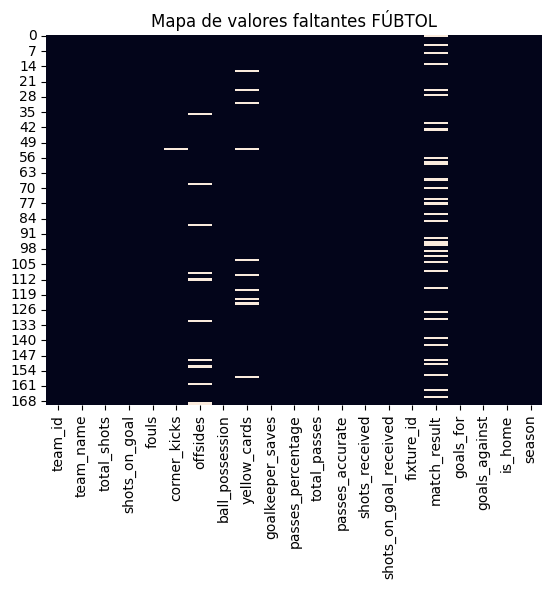

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

display(missing_summary)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes FÚBTOL")
plt.show()


### **<font color='orange'>Estadísticas descriptivas y de frecuencia</font>**

In [ ]:
df.drop(columns=['team_id', 'fixture_id', 'season']).describe().T

,count,mean,std,min,25%,50%,75%,max
total_shots,170.0,14.894118,5.376969,2.00,11.25,14.00,18.00,36.00
shots_on_goal,170.0,5.347059,2.658606,0.00,3.00,5.00,7.00,16.00
fouls,170.0,10.458824,3.784281,0.00,8.00,10.00,12.75,22.00
corner_kicks,169.0,6.177515,3.281146,1.00,3.00,5.00,8.00,17.00
offsides,160.0,1.956250,1.514487,0.00,1.00,2.00,3.00,7.00
ball_possession,170.0,0.566353,0.108288,0.23,0.49,0.57,0.65,0.81
yellow_cards,160.0,1.687500,1.249843,0.00,1.00,1.50,2.00,6.00
goalkeeper_saves,170.0,1.917647,1.600383,0.00,1.00,2.00,3.00,9.00
passes_percentage,170.0,0.854176,0.044010,0.70,0.83,0.86,0.88,0.93
total_passes,170.0,496.729412,118.784015,88.00,426.25,489.00,564.75,895.00


Nota: Match result se divide en

1.   True: Partido ganado
2.   False: Partido perdido
3.   None: Partido empatado



In [ ]:
df.drop(columns=['team_id', 'fixture_id']).describe(include=['object', 'bool']).T

,count,unique,top,freq
team_name,170,1,Arsenal,170
match_result,136,2,True,109
is_home,170,2,False,86


In [ ]:
display(df['match_result'].value_counts(dropna=False))

,count
match_result,
True,109
None,34
False,27


### Hacer el resultado del partido en categorías tipo 'one-hot-encoding'

* Victoria = 2
* Empate = 1
* Derrota = 0

In [ ]:
df['is_home'] = pd.Categorical(df['is_home'],
                                    categories=[True, False])

df['match_result'] = pd.Categorical(df['match_result'],
                                    categories=[True, False])

df_dummies = pd.get_dummies(df['match_result'],
                            prefix='res',
                            dummy_na=True)

df_dummies = df_dummies.rename(columns={
    'res_True': 'victoria',
    'res_False': 'derrota',
    'res_nan': 'empate'
})

df = pd.concat([df,
                df_dummies], axis=1)

mapping = {
    'victoria': 2, # Changed from 3 to 2
    'empate': 1,
    'derrota': 0
}

df['result_num'] = df[['victoria', 'empate', 'derrota']].idxmax(axis=1).map(mapping)

df.head(25)

,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,fixture_id,match_result,goals_for,goals_against,is_home,season,victoria,derrota,empate,result_num
0,42,Arsenal,17,4,11,3.0,2.0,0.65,1.0,1,...,1031535,NaN,1,1,False,2023,False,False,True,1
1,42,Arsenal,19,9,22,5.0,2.0,0.41,3.0,1,...,1030306,True,5,3,True,2023,True,False,False,2
2,42,Arsenal,15,7,12,8.0,2.0,0.78,2.0,1,...,1035038,True,2,1,True,2023,True,False,False,2
3,42,Arsenal,14,3,10,8.0,2.0,0.53,3.0,2,...,1035048,True,1,0,False,2023,True,False,False,2
4,42,Arsenal,19,11,6,8.0,4.0,0.71,0.0,1,...,1035058,NaN,2,2,True,2023,False,False,True,1
5,42,Arsenal,17,5,8,12.0,2.0,0.55,2.0,1,...,1035067,True,3,1,True,2023,True,False,False,2
6,42,Arsenal,13,4,10,11.0,4.0,0.74,1.0,1,...,1035079,True,1,0,False,2023,True,False,False,2
7,42,Arsenal,17,8,9,4.0,3.0,0.59,1.0,4,...,1126156,True,4,0,True,2023,True,False,False,2
8,42,Arsenal,13,6,12,11.0,2.0,0.47,3.0,3,...,1035087,NaN,2,2,True,2023,False,False,True,1
9,42,Arsenal,10,3,10,3.0,0.0,0.59,2.0,3,...,1125706,True,1,0,False,2023,True,False,False,2


### Eliminamos columnas que repiten información o cuyo valor no es relevante

In [ ]:
columns_to_drop = ['team_id', 'team_name', 'fixture_id',
                   'match_result',
                   'victoria', 'derrota', 'empate']

df = df.drop(columns_to_drop, axis=1)

df.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,season,result_num
0,17,4,11,3.0,2.0,0.65,1.0,1,0.90,624,564,12,2,1,1,False,2023,1
1,19,9,22,5.0,2.0,0.41,3.0,1,0.82,285,234,9,4,5,3,True,2023,2


### **<font color='pink'>Matriz de correlación</font>**

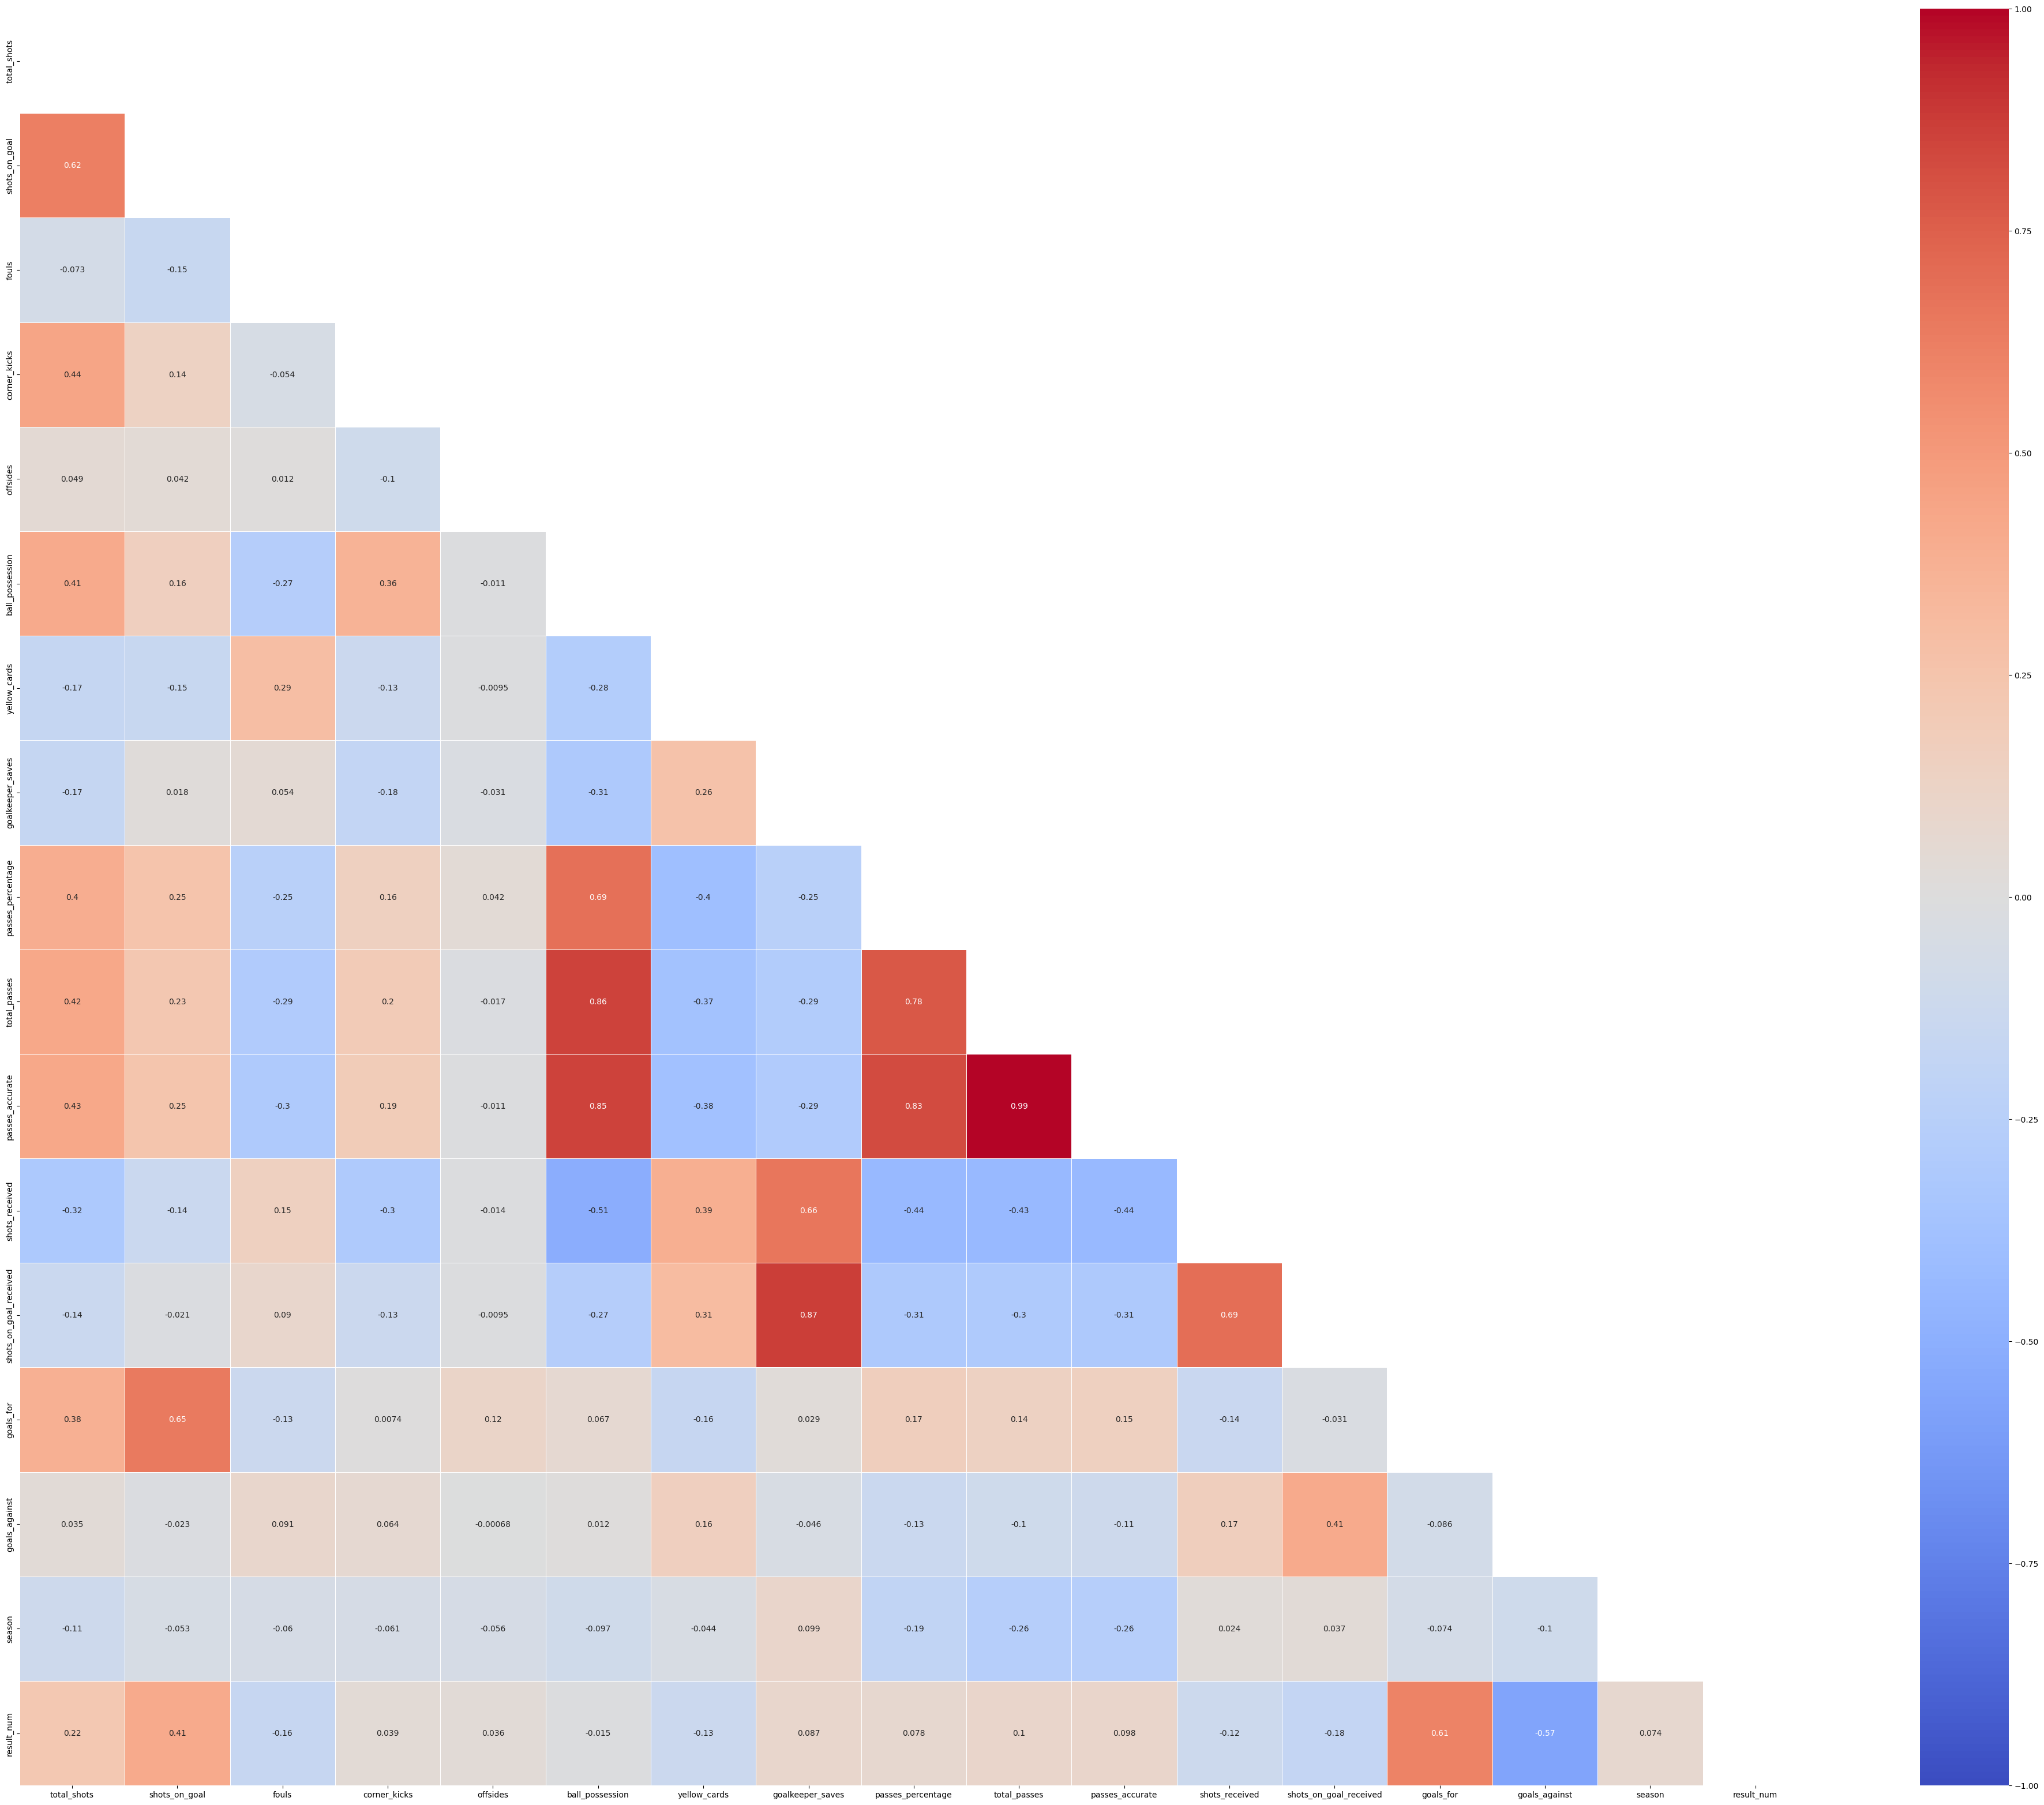

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(50, 40))
sns.heatmap(
    corr_matrix,
    mask=mask,       # Aplicar la máscara
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.show()

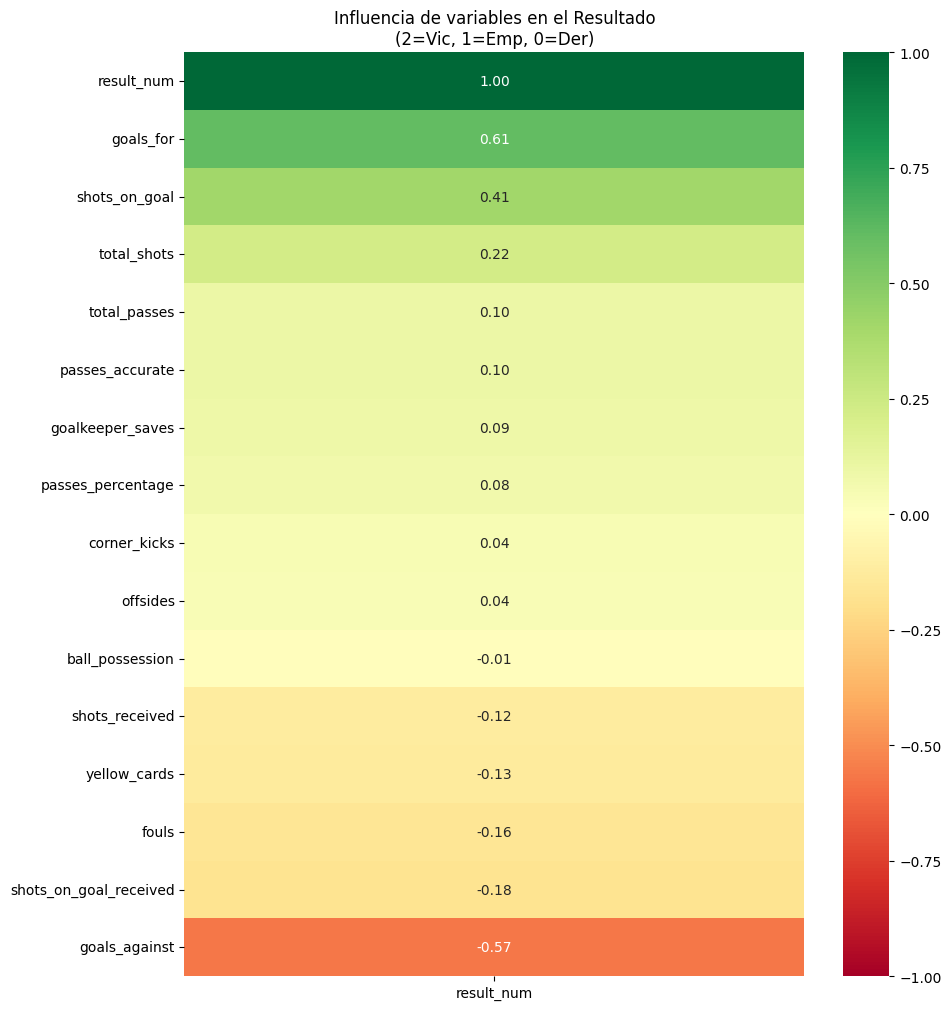

In [ ]:
plt.figure(figsize=(10, 12))

# Ordenamos las correlaciones respecto a 'result_num'
res_corr = corr_matrix[['result_num']].sort_values(by='result_num', ascending=False)

sns.heatmap(
    res_corr,
    annot=True,
    cmap='RdYlGn', # Verde para correlación positiva (victoria), rojo para negativa
    vmin=-1, vmax=1,
    fmt=".2f"
)

plt.title('Influencia de variables en el Resultado\n(2=Vic, 1=Emp, 0=Der)')
plt.show()

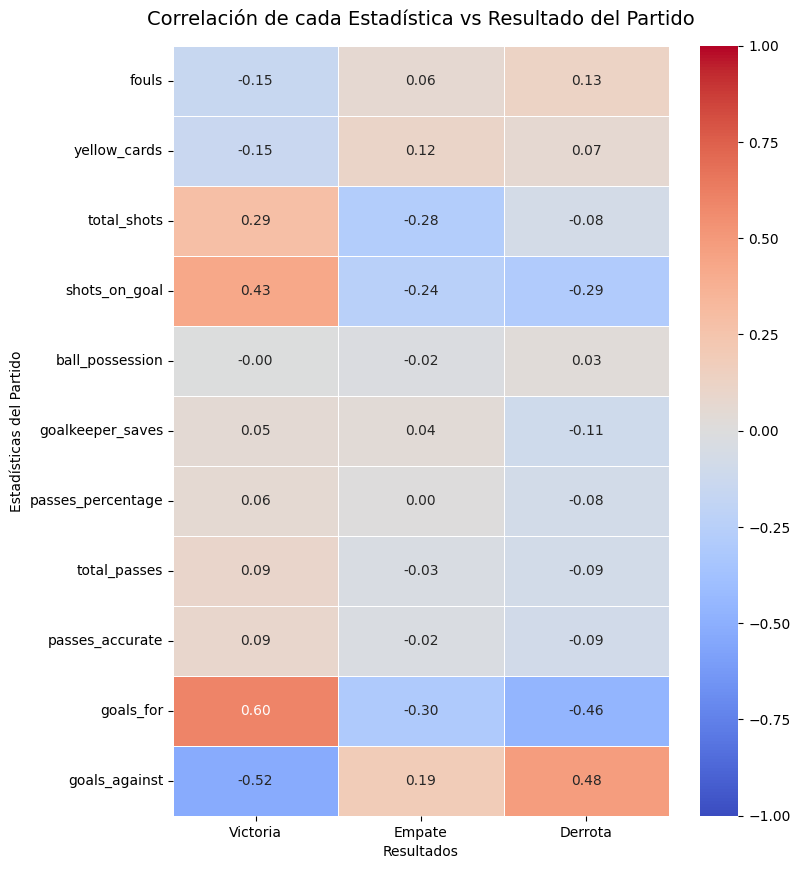

In [ ]:
# 1. Creamos variables temporales binarias (1 si ocurre, 0 si no)
df_temp = df.copy()
df_temp['Victoria'] = (df_temp['result_num'] == 2).astype(int)
df_temp['Empate'] = (df_temp['result_num'] == 1).astype(int)
df_temp['Derrota'] = (df_temp['result_num'] == 0).astype(int)

# 2. Definimos las columnas de resultados y las estadísticas que ya tenías
col_resultados = ['Victoria', 'Empate', 'Derrota']
colums_analyze = ['fouls', 'yellow_cards', 'total_shots', 'shots_on_goal',
                  'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# 3. Calculamos la correlación solo entre estadísticas y los resultados
corr_resultados = df_temp[colums_analyze + col_resultados].corr().loc[colums_analyze, col_resultados]

# 4. Graficamos el Heatmap aislado
plt.figure(figsize=(8, 10)) # Un tamaño más vertical y cómodo de leer
sns.heatmap(
    corr_resultados,
    annot=True,       # Muestra el número
    fmt=".2f",        # 2 decimales
    cmap='coolwarm',  # Azul (negativo), Rojo (positivo)
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlación de cada Estadística vs Resultado del Partido', fontsize=14, pad=15)
plt.ylabel('Estadísticas del Partido')
plt.xlabel('Resultados')
plt.show()

### **<font color='pink'>Outliers</font>**

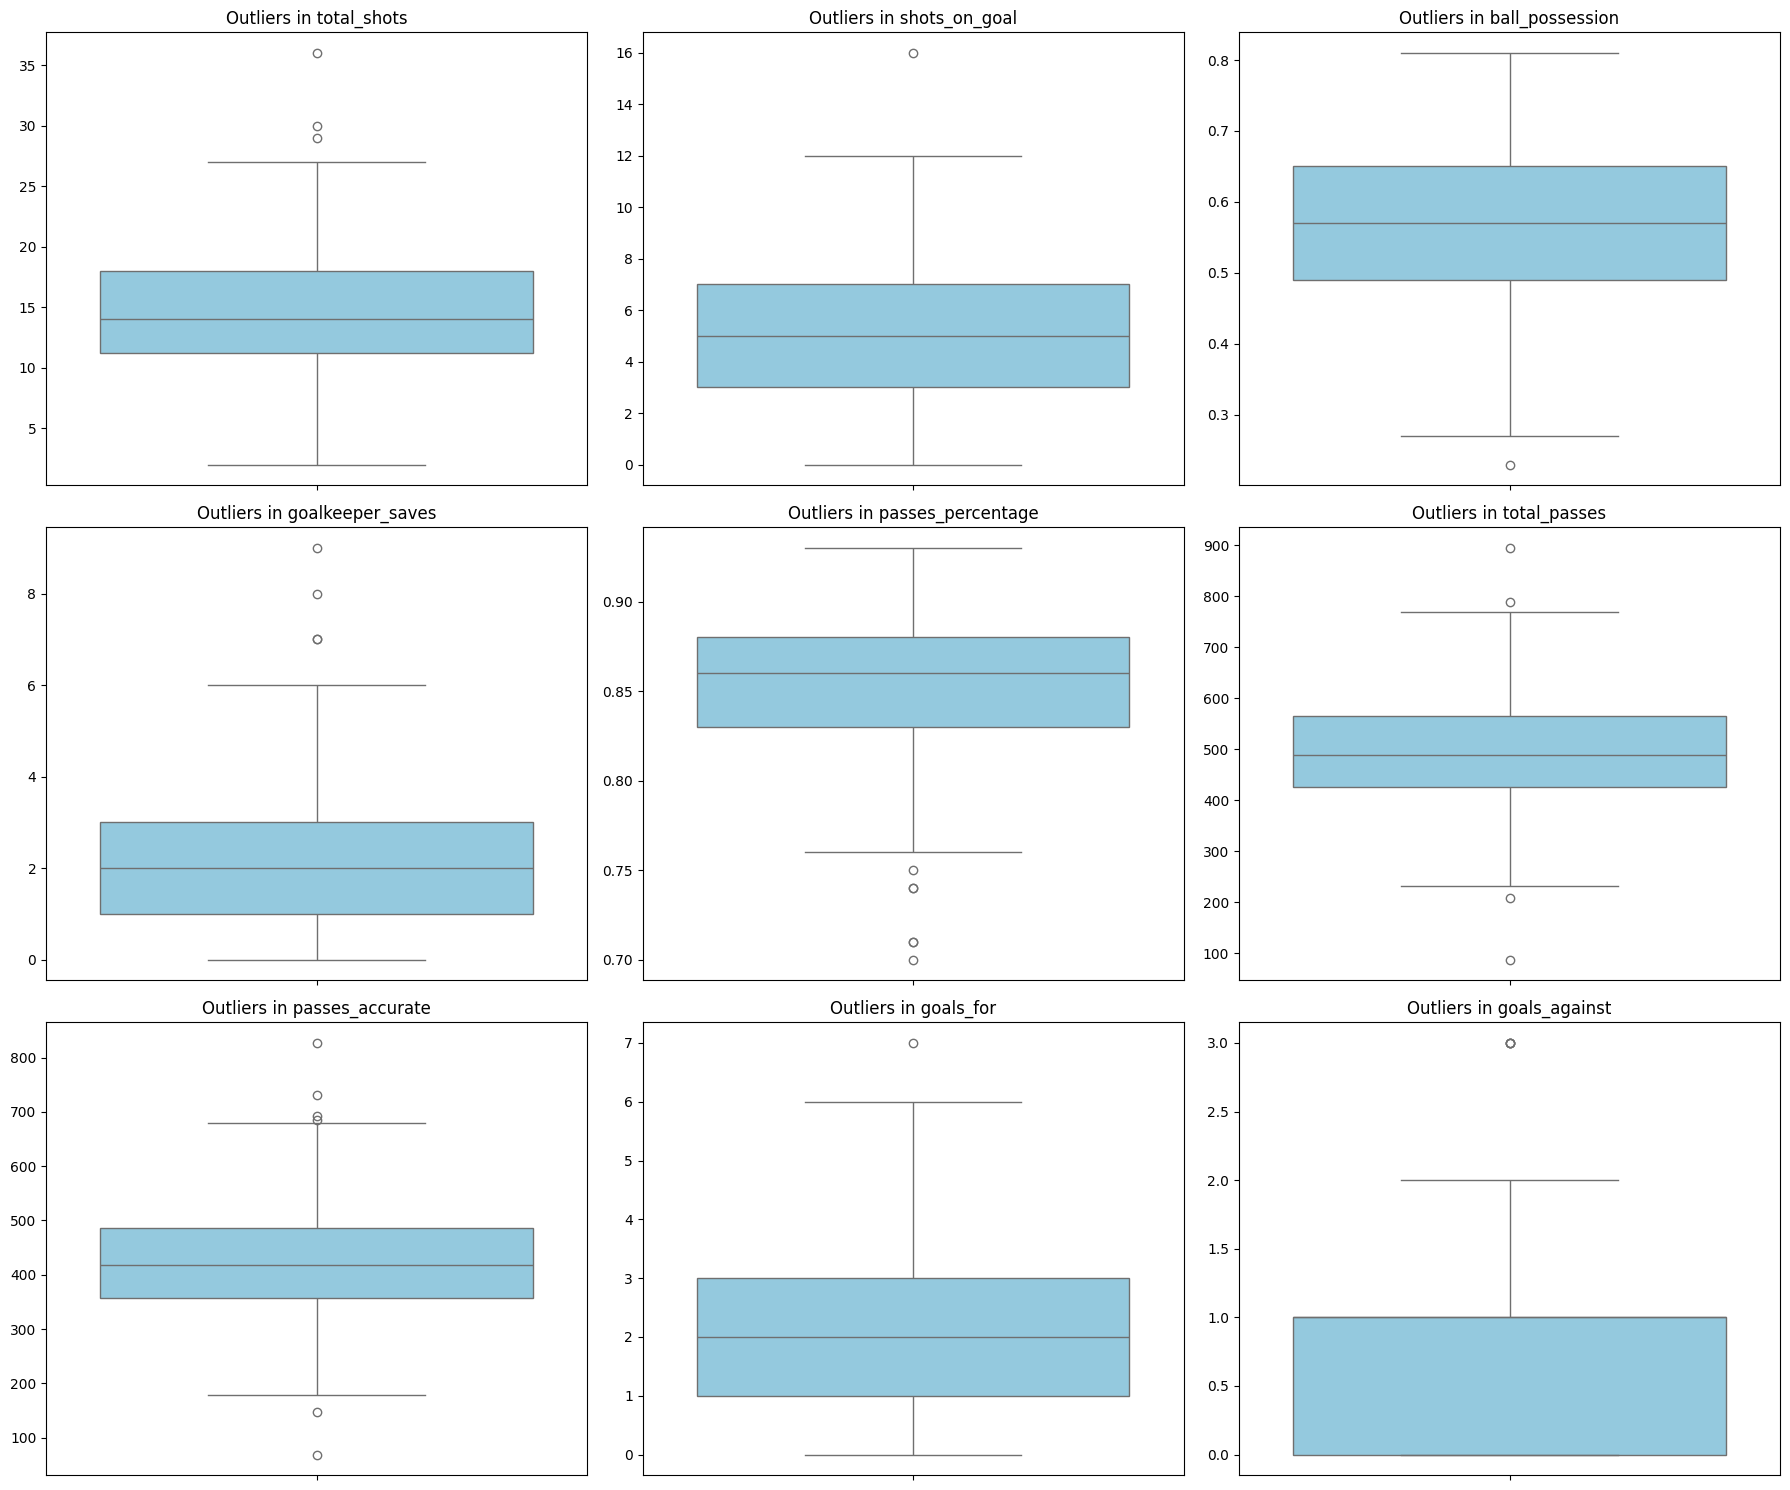

In [ ]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# Configuramos el número de columnas y calculamos las filas necesarias
cols = 3
rows = math.ceil(len(colums_analyze) / cols)

# Creamos la base del cuadro (el lienzo grande)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

for i, col in enumerate(colums_analyze):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_ylabel('') # Limpiamos el nombre del eje Y para que se vea más estético

plt.tight_layout()
plt.show()

### **<font color='pink'>Victorias, Empates y Derrotas (local vs visitante)</font>**

In [ ]:
match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)
match_is_home_count

/tmp/ipykernel_15774/632641939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)


result_num,0,1,2
is_home,,,
True,10,13,61
False,17,21,48


In [ ]:
result = pd.crosstab(df['is_home'], df['result_num'], normalize='index')
result

result_num,0,1,2
is_home,,,
True,0.119048,0.154762,0.72619
False,0.197674,0.244186,0.55814


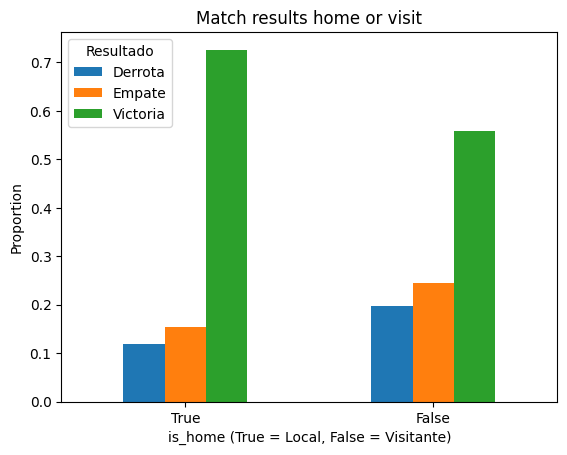

In [ ]:
result.plot(kind='bar')

plt.title('Match results home or visit')
plt.xlabel('is_home (True = Local, False = Visitante)')
plt.ylabel('Proportion')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper left')
plt.xticks(rotation=0)

plt.show()

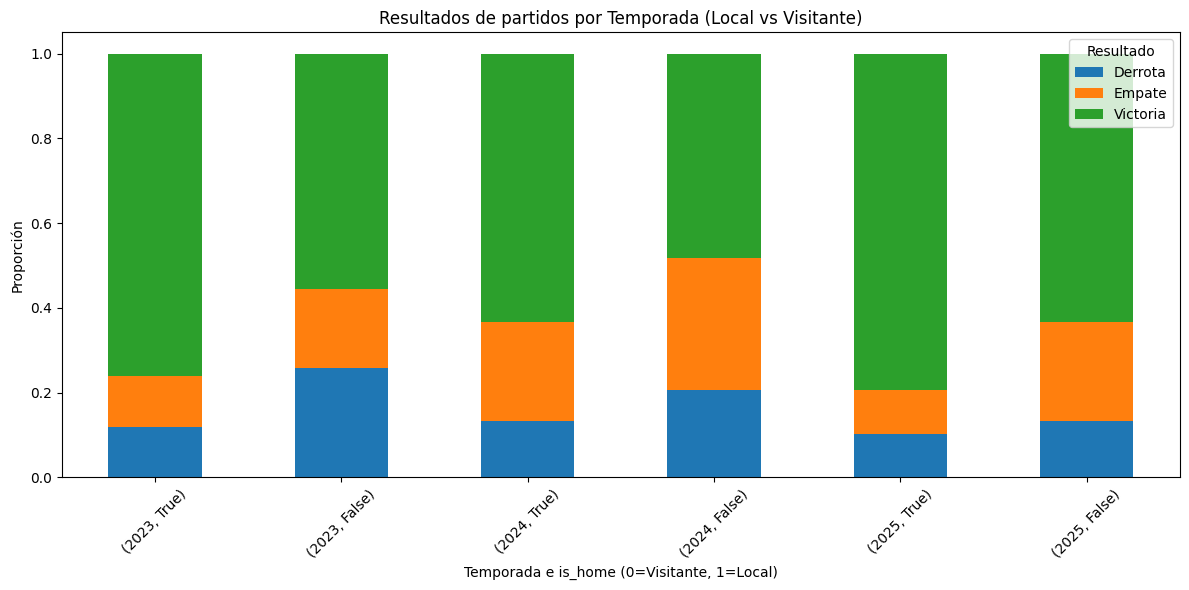

In [ ]:
result_evolucion = pd.crosstab(index=[df['season'], df['is_home']],
                               columns=df['result_num'],
                               normalize='index')

ax = result_evolucion.plot(kind='bar', figsize=(12, 6), stacked=True)

plt.title('Resultados de partidos por Temporada (Local vs Visitante)')
plt.xlabel('Temporada e is_home (0=Visitante, 1=Local)')
plt.ylabel('Proporción')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **<font color='pink'>Histogramas</font>**

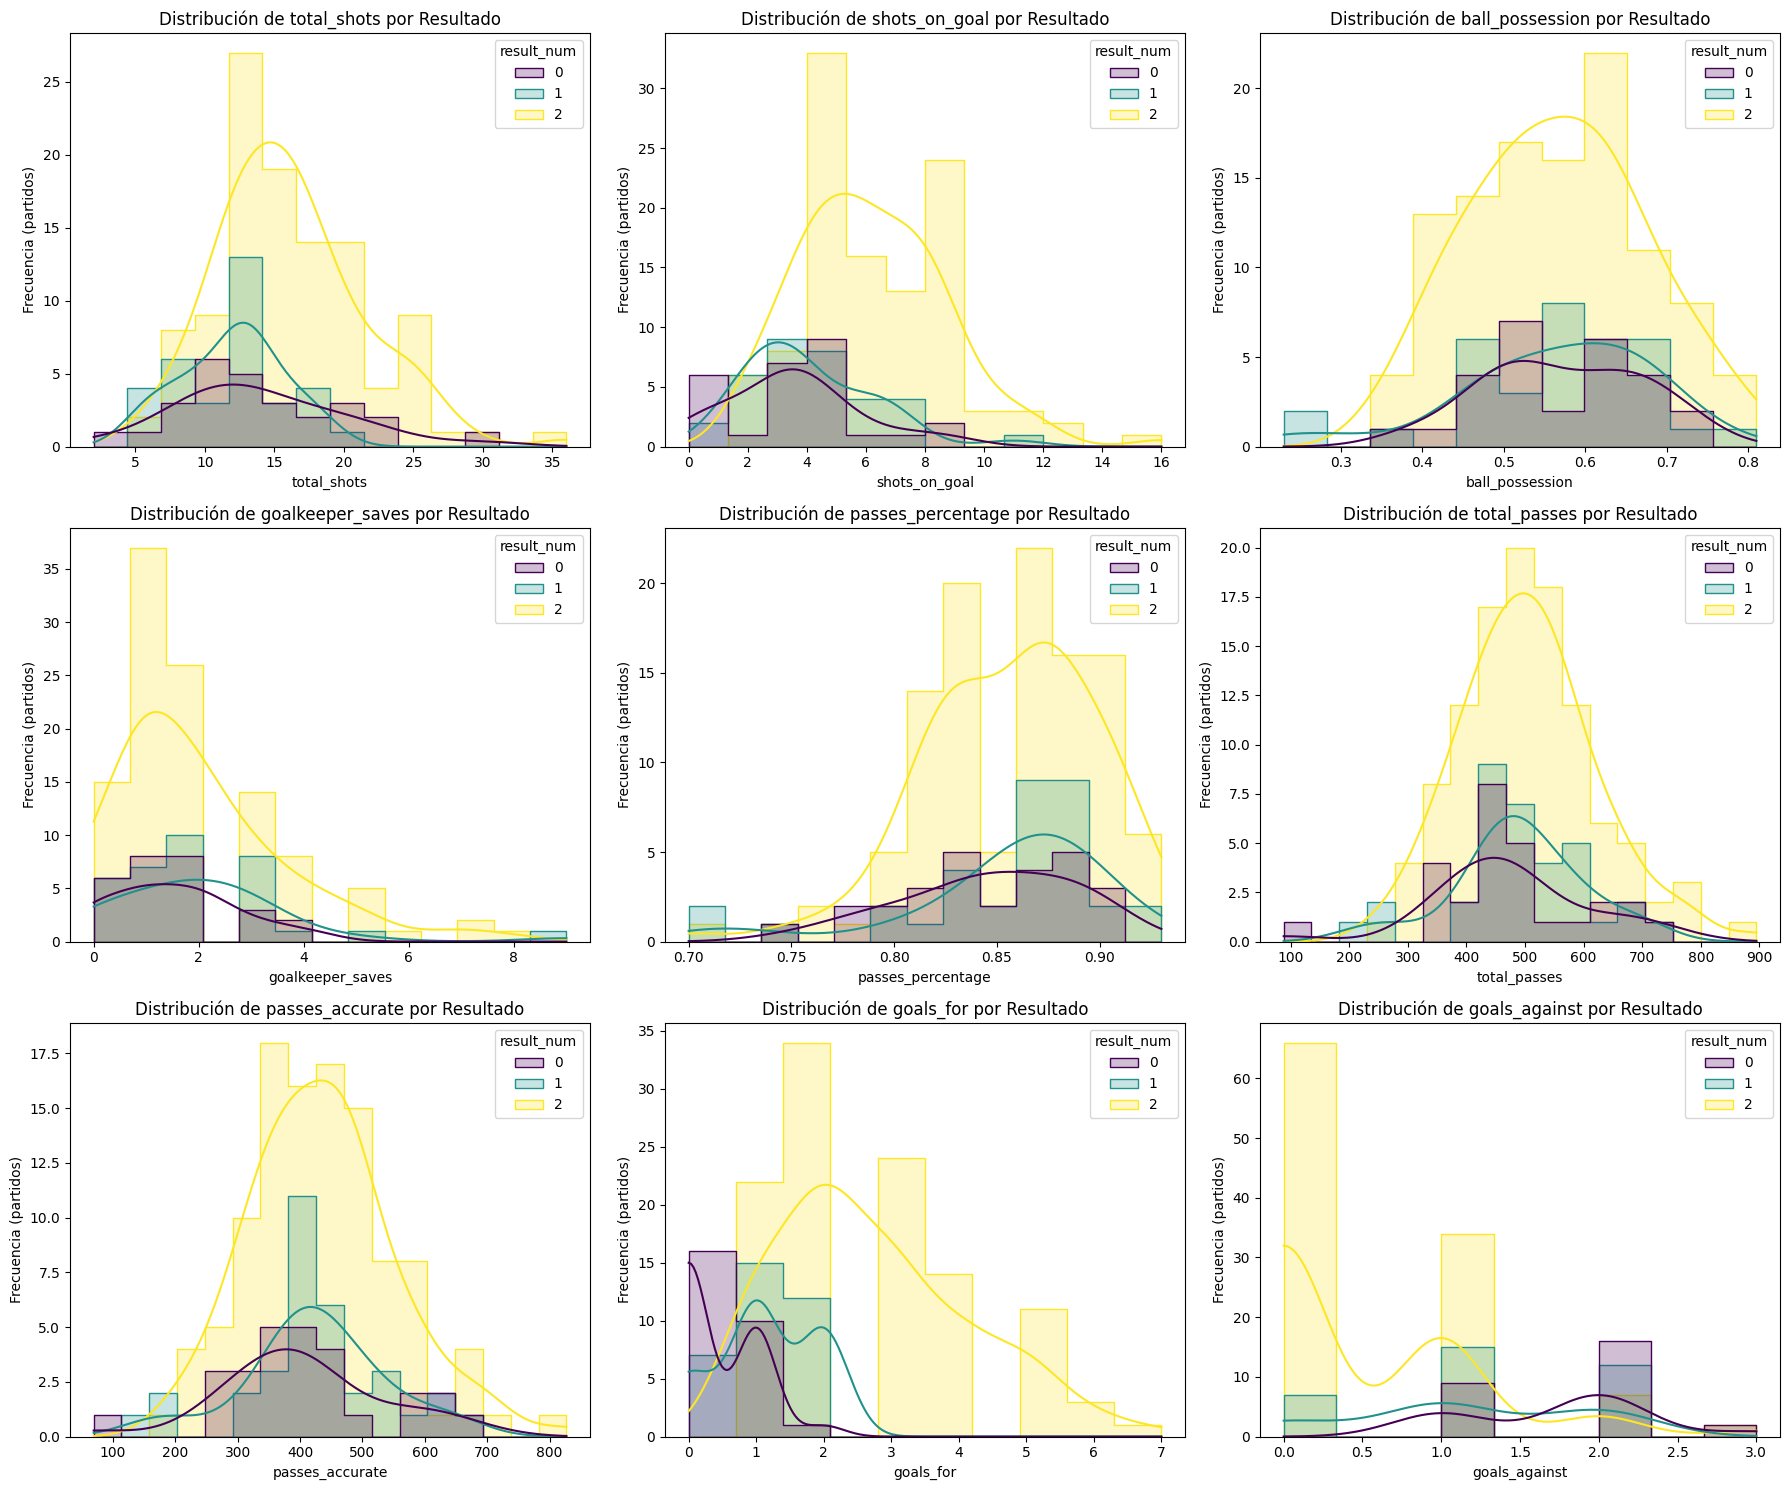

In [ ]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df,
                 x=col,
                 hue='result_num',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Resultado', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Frecuencia (partidos)')

plt.tight_layout()
plt.show()

### **<font color='pink'>Valores nulos</font>**

<Axes: >

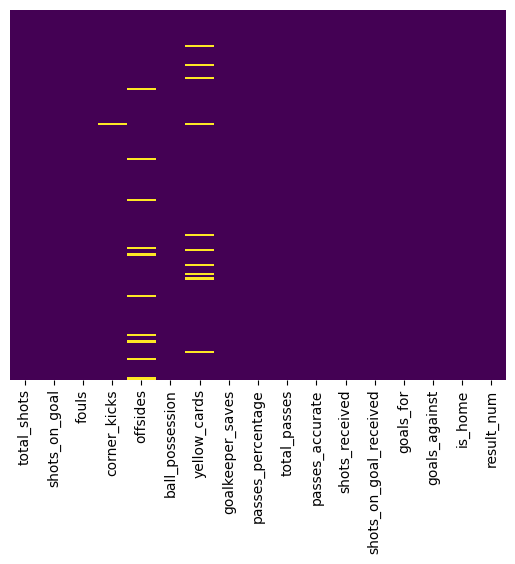

In [ ]:
sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

### **<font color='green'>Preprocesamiento (Eliminar columunas con valores faltantes)</font>**

In [ ]:
columns_drop = ['offsides', 'yellow_cards']

df_production = df.drop(columns_drop, axis=1)

df_production.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,ball_possession,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,result_num
0,17,4,11,3.0,0.65,1,0.90,624,564,12,2,1,1,False,1
1,19,9,22,5.0,0.41,1,0.82,285,234,9,4,5,3,True,2


In [ ]:
display(df_production.isnull().sum())

,0
total_shots,0
shots_on_goal,0
fouls,0
corner_kicks,1
ball_possession,0
goalkeeper_saves,0
passes_percentage,0
total_passes,0
passes_accurate,0
shots_received,0


## 🔨 **Ingeniería de características** (Avance 2)

### Obtener dataset de partidos (información general)

In [9]:
df_api = get_general_results_matches_all_teams()

SEASON: 2021
ID LEAGUE: 39
No. errors:  0
No. results:  380
----



SEASON: 2022
ID LEAGUE: 39
No. errors:  0
No. results:  380
----



SEASON: 2023
ID LEAGUE: 39
No. errors:  0
No. results:  380
----



SEASON: 2024
ID LEAGUE: 39
No. errors:  0
No. results:  380
----



SEASON: 2025
ID LEAGUE: 39
No. errors:  0
No. results:  380
----



SEASON: 2026
ID LEAGUE: 39
No. errors:  0
No. results:  0
----





In [17]:
df = df_api.copy()

In [18]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)
display(df.shape)
display(df.head(2))

(1879, 7)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals
0,710556,2021,2021-08-13 19:00:00+00:00,Brentford,Arsenal,2,0
1,710561,2021,2021-08-14 11:30:00+00:00,Manchester United,Leeds,5,1


### **<font color='orange'>ELO Ranking avanzado</font>**

#### Inicializamos a todos los equipos otorgando un valor inicial de 1,500 pts

In [19]:
teams = pd.concat([df['home_team'], df['away_team']]).unique()
elo_dictionary = {team: 1500 for team in teams}
elo_dictionary

{'Brentford': 1500,
 'Manchester United': 1500,
 'Watford': 1500,
 'Burnley': 1500,
 'Everton': 1500,
 'Leicester': 1500,
 'Chelsea': 1500,
 'Norwich': 1500,
 'Newcastle': 1500,
 'Tottenham': 1500,
 'Liverpool': 1500,
 'Aston Villa': 1500,
 'Leeds': 1500,
 'Manchester City': 1500,
 'Crystal Palace': 1500,
 'Brighton': 1500,
 'Wolves': 1500,
 'Southampton': 1500,
 'Arsenal': 1500,
 'West Ham': 1500,
 'Fulham': 1500,
 'Bournemouth': 1500,
 'Nottingham Forest': 1500,
 'Sheffield Utd': 1500,
 'Luton': 1500,
 'Ipswich': 1500,
 'Sunderland': 1500}

#### Función para hacer un reinicio de los pts de los equipos

* Cada nueva temporada tenemos que hacer un reinicio parcial de los pts obtenidos, esto es debido a que los equipos se refuerzan o desarman, cambian de DT, compran y venden jugadores, personal, etc.

* Actualmente nos quedamos con el 0.33% de los puntos obtenidos en la campaña.

In [20]:
def reboot_elo_new_seasson(elo_dictionary):

  for team, elo in elo_dictionary.items():
    #print(team, elo)
    #elo_dictionary[team] = (elo * 0.75) + (1500 * 0.25)
    elo_dictionary[team] = (elo * 0.67) + (1500 * 0.33)

#### Función para crear la tabla ELO hasta el último partido registrado

In [21]:
# HFA = ventaja de local (Home Field Advantage)
# K = Es un valor dinámico (respecto al torneo) para darle variedad a la puntuación
K, HFA = 20, 53
test_reboot_elo_ranking = True

# Listas temporales para guardar el estado ANTES del partido
elo_home_pre = []
elo_away_pre = []

current_year = int(AVAILABLE_SEASSONS[0])

# Recorremos todos los partidos
for index, row in df.iterrows():

  if row['season'] != current_year and test_reboot_elo_ranking:
    display(f"Last year: {current_year} // Current year {row['season']}")
    current_year = row['season']
    reboot_elo_new_seasson(elo_dictionary)

  home = row['home_team']
  away = row['away_team']
  goals_h = row['home_goals']
  goals_a = row['away_goals']

  # 1. Leer el elo actual de los equipos
  elo_current_h = elo_dictionary[home]
  elo_current_a = elo_dictionary[away]


  if index == 0:
    display(home)
    display(away)
    display(f"H: {elo_current_h} // A: {elo_current_a}")

  # 2. Guardarlo para el modelo predictivo
  elo_home_pre.append(elo_current_h)
  elo_away_pre.append(elo_current_a)

  # 3. Calcular la probabilidad con la fórmula de elo
  # Agregamos +100 al local para simular la ventaja de jugar en casa (Home Field Advantage)
  E_home = 1 / (1 + 10 ** (((elo_current_a) - (elo_current_h + HFA)) / 400))
  E_away = 1 - E_home

  # 4. Determinar el resultado real
  # (1 = gana local, 0.5 = empate, 0 = gana visita)
  if goals_h > goals_a:
      S_home, S_away = 1, 0
  elif goals_h == goals_a:
      S_home, S_away = 0.5, 0.5
  else:
      S_home, S_away = 0, 1

  # 5. Multiplicar por el margen de victoria
  # Un 4-0 demuestra más superioridad que un 1-0
  # Usamos la raíz cuadrada de la diferencia para amplificar un resultado grande
  margin_goals = abs(goals_h - goals_a)
  margin_multiplier = math.sqrt(margin_goals) if margin_goals > 0 else 1.0

  # 6. Calcular los puntos ganados en el partido
  change_elo_home = K * margin_multiplier * (S_home - E_home)
  change_elo_away = K * margin_multiplier * (S_away - E_away)

  # 7. Actualizar el diccionario de los equipos con los elo
  elo_dictionary[home] = elo_current_h + change_elo_home
  elo_dictionary[away] = elo_current_a + change_elo_away

  # ¿No se debería ir actualizando el ELO respecto a cada partido?
  # 8. Añadir el elo al dataframe
  df.at[index, 'Elo_Home_Pre'] = elo_current_h
  df.at[index, 'Elo_Away_Pre'] = elo_current_a
  df.at[index, 'Elo_Diff'] = (elo_current_h - elo_current_a)

'Brentford'

'Arsenal'

'H: 1500 // A: 1500'

'Last year: 2021 // Current year 2022'

'Last year: 2022 // Current year 2023'

'Last year: 2023 // Current year 2024'

'Last year: 2024 // Current year 2025'

In [22]:
df

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,710556,2021,2021-08-13 19:00:00+00:00,Brentford,Arsenal,2,0,1500.000000,1500.000000,0.000000
1,710561,2021,2021-08-14 11:30:00+00:00,Manchester United,Leeds,5,1,1500.000000,1500.000000,0.000000
2,710565,2021,2021-08-14 14:00:00+00:00,Watford,Aston Villa,3,2,1500.000000,1500.000000,0.000000
3,710557,2021,2021-08-14 14:00:00+00:00,Burnley,Brighton,1,2,1500.000000,1500.000000,0.000000
4,710559,2021,2021-08-14 14:00:00+00:00,Everton,Southampton,3,1,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
1874,1379320,2025,2026-05-10 13:00:00+00:00,Burnley,Aston Villa,2,2,1341.663227,1550.093048,-208.429821
1875,1379321,2025,2026-05-10 13:00:00+00:00,Crystal Palace,Everton,2,2,1494.878200,1528.914755,-34.036555
1876,1379325,2025,2026-05-10 13:00:00+00:00,Nottingham Forest,Newcastle,1,1,1540.799799,1524.110042,16.689757
1877,1379328,2025,2026-05-10 15:30:00+00:00,West Ham,Arsenal,0,1,1462.469333,1710.166181,-247.696848


#### <font color=pink>Observar el ELO ranking final</font>

In [23]:
display(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).head(30))

,0
Arsenal,1715.08
Manchester City,1709.64
Liverpool,1608.49
Manchester United,1599.74
Bournemouth,1580.45
Brighton,1569.31
Aston Villa,1545.90
Nottingham Forest,1538.82
Brentford,1538.54
Everton,1529.46


In [24]:
len(df)

1879

### **Standard Scaler**

In [35]:
df.head(2)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,710556,2021,2021-08-13 19:00:00+00:00,Brentford,Arsenal,2,0,1500.0,1500.0,0.0
1,710561,2021,2021-08-14 11:30:00+00:00,Manchester United,Leeds,5,1,1500.0,1500.0,0.0


In [31]:
# El número de partidos que tienen exactamente 1500
# estos partidos son los que iniciaron nuestra puntuación elo
df_test = df[df['Elo_Home_Pre'] == 1500].copy()
len(df_test)

15

In [36]:
SCALER = StandardScaler()

X_local = df[['Elo_Home_Pre', 'Elo_Away_Pre']]
y_local = df['home_goals']

X_away = df[['Elo_Away_Pre', 'Elo_Home_Pre']]
y_away = df['away_goals']

X_local_scaled = SCALER.fit_transform(X_local)
X_away_scaled = SCALER.fit_transform(X_away)


In [38]:
display(X_local_scaled)
display(X_away_scaled)

array([[-0.20780639, -0.20596881],
       [-0.20780639, -0.20596881],
       [-0.20780639, -0.20596881],
       ...,
       [ 0.27187471,  0.07694466],
       [-0.64905247,  2.26017549],
       [-0.86797949, -0.0610263 ]])

array([[-0.20596881, -0.20780639],
       [-0.20596881, -0.20780639],
       [-0.20596881, -0.20780639],
       ...,
       [ 0.07694466,  0.27187471],
       [ 2.26017549, -0.64905247],
       [-0.0610263 , -0.86797949]])

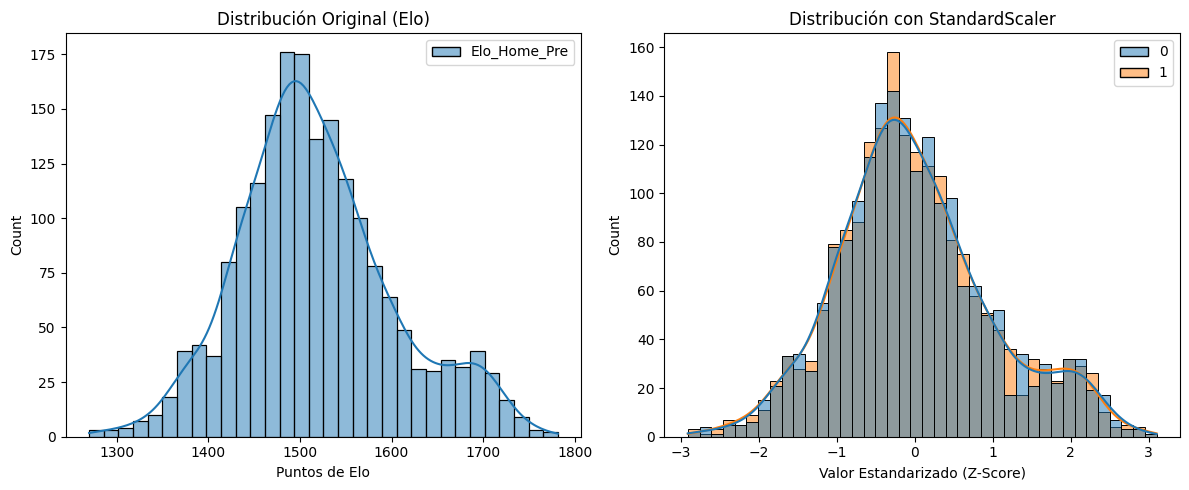

In [40]:
elo_original = df[['Elo_Home_Pre']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Antes del escalado
sns.histplot(elo_original, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribución Original (Elo)')
ax1.set_xlabel('Puntos de Elo')

# Gráfico 2: Después del escalado
sns.histplot(X_local_scaled, kde=True, color='olive', ax=ax2)
ax2.set_title('Distribución con StandardScaler')
ax2.set_xlabel('Valor Estandarizado (Z-Score)')

plt.tight_layout()
plt.show()